In [1]:
from pathlib import Path
import pandas as pd

data_path = Path("molecular+biology+promoter+gene+sequences/promoters.data")

df = pd.read_csv(
    data_path,
    header=None, # 첫 줄부터 바로 데이터가 시작되니까 헤더가 없다고 명시한 것
    names=["label", "name", "sequence"] # 따로 컬럼 이름을 지정해준 것
)

print(df.head())
print(df.info())
print(df["label"].value_counts())

  label       name                                           sequence
0     +        S10  \t\ttactagcaatacgcttgcgttcggtggttaagtatgtataat...
1     +       AMPC  \t\ttgctatcctgacagttgtcacgctgattggtgtcgttacaat...
2     +       AROH  \t\tgtactagagaactagtgcattagcttatttttttgttatcat...
3     +      DEOP2  \taattgtgatgtgtatcgaagtgtgttgcggagtagatgttagaa...
4     +  LEU1_TRNA  \ttcgataattaactattgacgaaaagctgaaaaccactagaatgc...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   label     106 non-null    object
 1   name      106 non-null    object
 2   sequence  106 non-null    object
dtypes: object(3)
memory usage: 2.6+ KB
None
label
+    53
-    53
Name: count, dtype: int64


In [2]:
# Quest 2. 실제 데이터 전처리

df["sequence"] = df["sequence"].str.replace("\t", "", regex=False) # 시퀀스에서 탭 문자를 제거
df["sequence"] = df["sequence"].str.replace(" ", "", regex=False) # 시퀀스에서 공백 문자를 제거
df["sequence"] = df["sequence"].str.upper() # 시퀀스를 대문자로 변환

df["target"] = df["label"].map({
    "+": 1, # 1 = promoter
    "-": 0 # 0 = non-promoter
    }) # 머신러닝 모델이 사용할 수 있도록 정답 라벨을 숫자로 변환하여 새로운 컬럼에 저장

print(df.head())
print(df["sequence"].head())
print(df["target"].value_counts())

  label       name                                           sequence  target
0     +        S10  TACTAGCAATACGCTTGCGTTCGGTGGTTAAGTATGTATAATGCGC...       1
1     +       AMPC  TGCTATCCTGACAGTTGTCACGCTGATTGGTGTCGTTACAATCTAA...       1
2     +       AROH  GTACTAGAGAACTAGTGCATTAGCTTATTTTTTTGTTATCATGCTA...       1
3     +      DEOP2  AATTGTGATGTGTATCGAAGTGTGTTGCGGAGTAGATGTTAGAATA...       1
4     +  LEU1_TRNA  TCGATAATTAACTATTGACGAAAAGCTGAAAACCACTAGAATGCGC...       1
0    TACTAGCAATACGCTTGCGTTCGGTGGTTAAGTATGTATAATGCGC...
1    TGCTATCCTGACAGTTGTCACGCTGATTGGTGTCGTTACAATCTAA...
2    GTACTAGAGAACTAGTGCATTAGCTTATTTTTTTGTTATCATGCTA...
3    AATTGTGATGTGTATCGAAGTGTGTTGCGGAGTAGATGTTAGAATA...
4    TCGATAATTAACTATTGACGAAAAGCTGAAAACCACTAGAATGCGC...
Name: sequence, dtype: object
target
1    53
0    53
Name: count, dtype: int64


문자열 정리 → 정답 라벨 숫자화 → 모델이 사용할 수 있는 형태로 준비

In [3]:
# Quest 3. DNA 데이터 검증하기

df["sequence_length"] = df["sequence"].str.len() # 시퀀스의 길이를 계산하여 새로운 컬럼에 저장

print(df["sequence_length"].describe())
print(df["sequence_length"].value_counts())

valid_bases = set("ATGC") # 유효한 염기 서열을 정의

def check_invalid_bases(sequence):
    sequence_bases = set(sequence) # 시퀀스에서 사용된 염기 서열을 집합으로 만듦
    invalid_bases = sequence_bases - valid_bases # 시퀀스에서 유효하지 않은 염기 서열을 찾음
    return invalid_bases

df["invalied_bases"] = df["sequence"].apply(check_invalid_bases) # 각 시퀀스에 대해 유효하지 않은 염기 서열을 계산하여 새로운 컬럼에 저장

print(df["invalied_bases"].value_counts())
print(df.isnull().sum())

count    106.0
mean      57.0
std        0.0
min       57.0
25%       57.0
50%       57.0
75%       57.0
max       57.0
Name: sequence_length, dtype: float64
sequence_length
57    106
Name: count, dtype: int64
invalied_bases
{}    106
Name: count, dtype: int64
label              0
name               0
sequence           0
target             0
sequence_length    0
invalied_bases     0
dtype: int64


데이터 검증 결과, 총 106개의 DNA sequence가 존재하며 모든 sequence의 길이는 57bp로 동일하였다. 또한 A/T/G/C 외의 문자는 발견되지 않았고, 결측치도 존재하지 않아 추가적인 결측치 처리나 sequence 필터링 없이 feature engineering을 진행할 수 있었다.

데이터 개수: 106개
sequence 길이: 전부 57bp
이상 염기: 없음
결측치: 없음

label
+    53
-    53
Name: count, dtype: int64


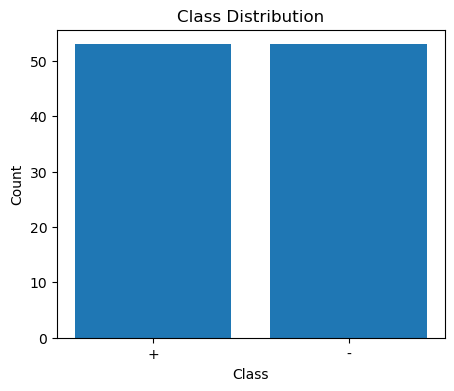

In [4]:
# Quest 4-1. EDA

import matplotlib.pyplot as plt

class_counts = df["label"].value_counts() # 라벨별로 데이터의 개수를 계산

print(class_counts)

plt.figure(figsize=(5,4))
plt.bar(class_counts.index, class_counts.values) # 라벨별로 막대 그래프를 그림
plt.title("Class Distribution") # 그래프 제목 설정
plt.xlabel("Class") # x축 레이블 설정
plt.ylabel("Count") # y축 레이블 설정
plt.show() # 그래프를 화면에 표시


클래스 분포를 확인한 결과 promoter와 non-promoter가 각각 53개로 동일하게 구성되어 있었다. 따라서 class imbalance에 따른 편향 가능성이 낮으며, 기본적인 분류 모델 학습에 적합한 구조임을 확인하였다.

GC content는 sequence에서 G와 C가 차지하는 비율입니다
G-C 결합은 A-T보다 수소결합이 더 많음
GC 비율은 DNA 안정성, 유전자 조절 영역 특성과 관련될 수 있음
promoter와 non-promoter 사이에 염기 조성 차이가 있는지 확인할 수 있음

In [5]:
# Quest 4-2. GC Content 분석

def calculate_gc_content(sequence):
    g_count = sequence.count("G") # 시퀀스에서 G의 개수를 셈
    c_count = sequence.count("C") # 시퀀스에서 C의 개수를 셈
    total_length = len(sequence) # 시퀀스의 총 길이를 계산

    gc_ratio = (g_count + c_count) / total_length
    return gc_ratio
df["gc_content"] = df["sequence"].apply(calculate_gc_content) # 각 시퀀스에 대해 GC 함량을 계산하여 새로운 컬럼에 저장 

print(df[["label", "sequence", "gc_content"]].head())

print(df.groupby("label")["gc_content"].describe()) # 라벨별로 GC 함량의 통계 요약을 계산하여 출력 

  label                                           sequence  gc_content
0     +  TACTAGCAATACGCTTGCGTTCGGTGGTTAAGTATGTATAATGCGC...    0.473684
1     +  TGCTATCCTGACAGTTGTCACGCTGATTGGTGTCGTTACAATCTAA...    0.473684
2     +  GTACTAGAGAACTAGTGCATTAGCTTATTTTTTTGTTATCATGCTA...    0.403509
3     +  AATTGTGATGTGTATCGAAGTGTGTTGCGGAGTAGATGTTAGAATA...    0.368421
4     +  TCGATAATTAACTATTGACGAAAAGCTGAAAACCACTAGAATGCGC...    0.421053
       count      mean       std       min       25%       50%       75%  \
label                                                                      
+       53.0  0.421384  0.083182  0.263158  0.368421  0.421053  0.473684   
-       53.0  0.490566  0.058588  0.333333  0.456140  0.473684  0.543860   

            max  
label            
+      0.649123  
-      0.596491  


non-promoter가 promoter보다 평균 GC content가 더 높다.
약 6.9%p 차이

GC content는 promoter/non-promoter 분류에 도움이 될 수 있는 feature이지만,
두 class의 분포가 완전히 분리되지는 않으므로 단독 feature로는 부족하다.

C:\Users\hakyh\AppData\Local\Temp\ipykernel_35072\924054190.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


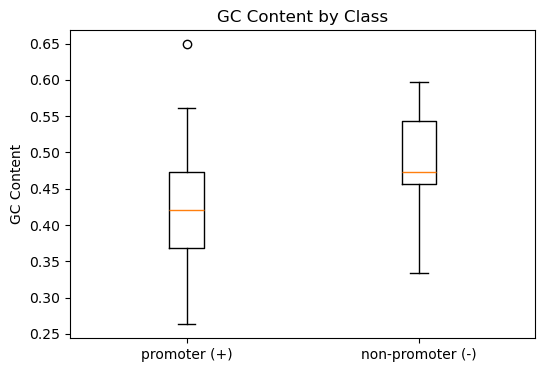

In [6]:
plt.figure(figsize=(6,4))
plt.boxplot(
    [
        df[df["label"] == "+" ]["gc_content"], # promoter 클래스의 GC 함량 데이터
        df[df["label"] == "-" ]["gc_content"], # non-promoter 클래스의 GC 함량 데이터
    ],
    labels = ["promoter (+)", "non-promoter (-)"] # 박스 플롯의 라벨 설정   
)

plt.title("GC Content by Class") # 그래프 제목 설정
plt.ylabel("GC Content") # y축 레이블 설정
plt.show() # 그래프를 화면에 표시

1. non-promoter 쪽이 전체적으로 더 높다
2. 완전히 분리되지는 않는다 (겹치는 분포가 있다)
GC content는 분류에 도움이 되는 feature이지만, 이것 하나만으로 promoter/non-promoter를 완벽히 구분할 수는 없다.
3. promoter 쪽에는 outlier가 있다
대부분의 promoter는 GC content가 낮은 편이지만, 일부 promoter sequence는 높은 GC content를 가진다.

In [7]:
# Quest 4-3. 염기 A/T/G/C 빈도 비교

def count_bases(sequence): # sequence 하나에서 A, T, G, C가 각각 몇 개 있는지 세는 함수
    return {
        "A": sequence.count("A"), # 시퀀스에서 A의 개수를 셈
        "T": sequence.count("T"), # 시퀀스에서 T의 개수를 셈
        "G": sequence.count("G"), # 시퀀스에서 G의 개수를 셈
        "C": sequence.count("C"), # 시퀀스에서 C의 개수를 셈
    }

base_counts = df["sequence"].apply(count_bases) # 각 시퀀스에 대해 염기 빈도를 계산하여 새로운 컬럼에 저장
base_counts_df = pd.DataFrame(base_counts.tolist()) # 염기 빈도 데이터를 데이터프레임으로 변환

df_with_bases = pd.concat([df, base_counts_df], axis=1) # 원래 데이터프레임과 염기 빈도 데이터프레임을 병합

print(df_with_bases[["label", "A", "T", "G", "C"]].head()) # 라벨과 염기 빈도 컬럼을 출력
print(df_with_bases.groupby("label")[["A", "T", "G", "C"]].describe()) # 라벨별로 염기 빈도의 통계 요약을 계산하여 출력 


  label   A   T   G   C
0     +  11  19  17  10
1     +  13  17  12  15
2     +  14  20  11  12
3     +  18  18  15   6
4     +  20  13  12  12
          A                                                       T  \
      count       mean       std  min   25%   50%   75%   max count   
label                                                                 
+      53.0  15.792453  3.996915  9.0  13.0  16.0  19.0  25.0  53.0   
-      53.0  13.924528  3.118487  8.0  12.0  14.0  16.0  24.0  53.0   

                  ...     G           C                                        \
            mean  ...   75%   max count       mean       std  min   25%   50%   
label             ...                                                           
+      17.188679  ...  14.0  21.0  53.0  12.622642  3.481967  5.0  11.0  12.0   
-      15.113208  ...  17.0  20.0  53.0  13.509434  2.531514  8.0  12.0  14.0   

                   
        75%   max  
label              
+      15.0  20.0  
-      15.0  2

promoter는 A/T 비율이 높고,
non-promoter는 G/C 비율이 상대적으로 높다.

Promoter 영역은 특정 motif나 전사 개시 관련 패턴 때문에 A/T-rich한 경향이 나타날 수 있습니다.
이 데이터에서도 promoter class가 A/T 염기를 상대적으로 더 많이 포함하는 경향을 보입니다.

In [8]:
base_mean = df_with_bases.groupby("label")[["A", "T", "G", "C"]].mean() # 라벨별로 염기 빈도의 평균을 계산하여 새로운 데이터프레임에 저장 

print(base_mean)

               A          T          G          C
label                                            
+      15.792453  17.188679  11.396226  12.622642
-      13.924528  15.113208  14.452830  13.509434


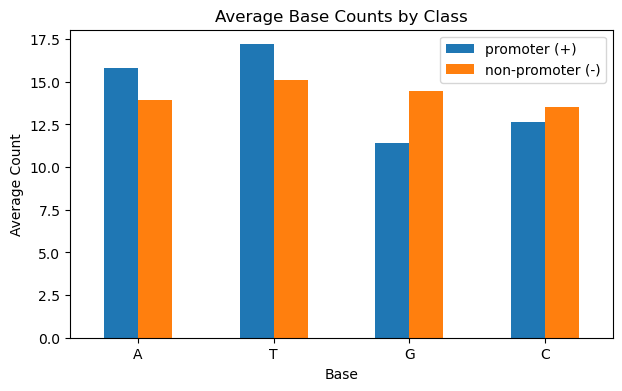

In [9]:
base_mean.T.plot(kind="bar", figsize=(7,4)) # 라벨별로 염기 빈도의 평균을 막대 그래프로 그림

plt.title("Average Base Counts by Class") # 그래프 제목 설정
plt.xlabel("Base") # x축 레이블 설정
plt.ylabel("Average Count") # y축 레이블 설정
plt.xticks(rotation=0) # x축 레이블의 회전 각도를 0도로 설정하여 가독성을 높임
plt.legend(["promoter (+)", "non-promoter (-)"]) # 범례 설정
plt.show() # 그래프를 화면에 표시

promoter는 상대적으로 A/T가 많고,
non-promoter는 상대적으로 G/C가 많다.

In [10]:
# Quest 4-4. 위치별 염기 패턴 보기
promoter_df = df[df["label"] == "+"] # promoter 클래스의 데이터만 필터링하여 새로운 데이터프레임에 저장

print(promoter_df.head())
print(len(promoter_df))

position_records = [] # 위치별 염기 패턴을 저장할 리스트

for sequence in promoter_df["sequence"]: # promoter 클래스의 각 시퀀스에 대해 반복
    for position, base in enumerate(sequence, start=1): # 시퀀스의 각 염기에 대해 위치와 염기 정보를 가져옴
        position_records.append({
            "position": position, # 염기의 위치 정보
            "base": base # 염기 정보
        })

position_df = pd.DataFrame(position_records) # 위치별 염기 패턴 데이터를 데이터프레임으로 변환

print(position_df.head())

  label       name                                           sequence  target  \
0     +        S10  TACTAGCAATACGCTTGCGTTCGGTGGTTAAGTATGTATAATGCGC...       1   
1     +       AMPC  TGCTATCCTGACAGTTGTCACGCTGATTGGTGTCGTTACAATCTAA...       1   
2     +       AROH  GTACTAGAGAACTAGTGCATTAGCTTATTTTTTTGTTATCATGCTA...       1   
3     +      DEOP2  AATTGTGATGTGTATCGAAGTGTGTTGCGGAGTAGATGTTAGAATA...       1   
4     +  LEU1_TRNA  TCGATAATTAACTATTGACGAAAAGCTGAAAACCACTAGAATGCGC...       1   

   sequence_length invalied_bases  gc_content  
0               57             {}    0.473684  
1               57             {}    0.473684  
2               57             {}    0.403509  
3               57             {}    0.368421  
4               57             {}    0.421053  
53
   position base
0         1    T
1         2    A
2         3    C
3         4    T
4         5    A


In [11]:
print(len(position_df))

3021


In [12]:
# 위치별 염기 빈도 계산
position_base_counts = (
    position_df
    .groupby(["position", "base"]) # 위치와 염기별로 그룹화
    .size() # 각 그룹의 크기를 계산하여 빈도 데이터로 만듦
    .reset_index(name="count") # 그룹화된 데이터의 인덱스를 초기화하고 빈도 데이터를 "count"라는 이름의 컬럼으로 만듦

)

print(position_base_counts.head(12))

    position base  count
0          1    A     14
1          1    C     12
2          1    G      8
3          1    T     19
4          2    A     17
5          2    C     15
6          2    G      7
7          2    T     14
8          3    A     14
9          3    C     10
10         3    G     15
11         3    T     14


In [13]:
position_base_counts["frequency"] = position_base_counts["count"] / len(promoter_df) # 각 위치와 염기 조합의 빈도를 promoter 클래스의 총 시퀀스 수로 나누어 계산하여 새로운 컬럼에 저장

print(position_base_counts.head(12))

    position base  count  frequency
0          1    A     14   0.264151
1          1    C     12   0.226415
2          1    G      8   0.150943
3          1    T     19   0.358491
4          2    A     17   0.320755
5          2    C     15   0.283019
6          2    G      7   0.132075
7          2    T     14   0.264151
8          3    A     14   0.264151
9          3    C     10   0.188679
10         3    G     15   0.283019
11         3    T     14   0.264151


frequency = 해당 위치에서 특정 염기가 등장한 비율

heatmap 그릴거임
행 = base
열 = position
값 = frequency

In [14]:
position_frequency_matrix = position_base_counts.pivot(
    index="base", # 염기 정보를 행 인덱스로 설정
    columns="position", # 위치 정보를 열 인덱스로 설정
    values="frequency" # 빈도 데이터를 값으로 설정
)
print(position_frequency_matrix)

position        1         2         3         4         5         6   \
base                                                                   
A         0.264151  0.320755  0.264151  0.207547  0.415094  0.603774   
C         0.226415  0.283019  0.188679  0.264151  0.188679  0.113208   
G         0.150943  0.132075  0.283019  0.264151  0.188679  0.094340   
T         0.358491  0.264151  0.264151  0.264151  0.207547  0.188679   

position        7         8         9         10  ...        48        49  \
base                                              ...                       
A         0.490566  0.377358  0.320755  0.490566  ...  0.264151  0.169811   
C         0.169811  0.094340  0.169811  0.132075  ...  0.377358  0.471698   
G         0.113208  0.132075  0.094340  0.132075  ...  0.169811  0.283019   
T         0.226415  0.396226  0.415094  0.245283  ...  0.188679  0.075472   

position        50        51        52        53        54        55  \
base                            

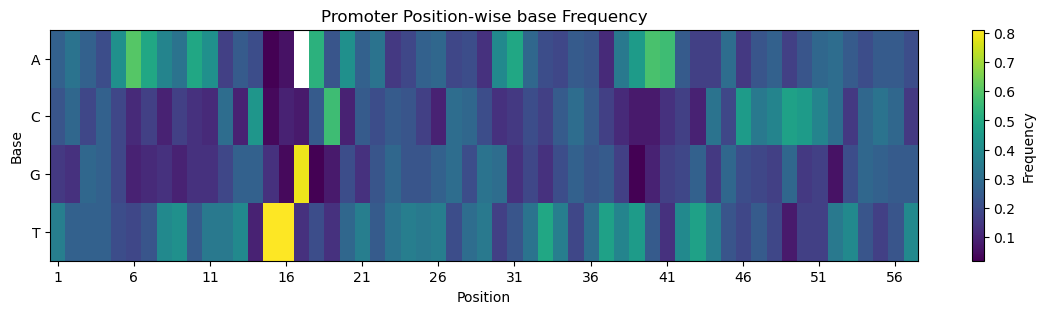

In [15]:
# Quest 4-4. Promoter 위치별 염기 Heatmap
import matplotlib.pyplot as plt

plt.figure(figsize=(14,3))
plt.imshow(position_frequency_matrix, aspect="auto", cmap="viridis") # 위치별 염기 빈도 데이터를 히트맵으로 시각화

plt.colorbar(label="Frequency") # 히트맵에 색상 막대 추가하여 빈도 값을 표시
plt.title("Promoter Position-wise base Frequency")
plt.xlabel("Position") # x축 레이블 설정
plt.ylabel("Base") # y축 레이블 설정

plt.yticks(
    ticks=range(len(position_frequency_matrix.index)), # y축 눈금 위치 설정
    labels=position_frequency_matrix.index # y축 눈금 레이블 설정
)

plt.xticks(
    ticks = range(0, 57, 5), # x축 눈금 위치 설정 (5 간격으로)
    labels = range(1, 58, 5) # x축 눈금 레이블 설정 (1부터 57까지 5 간격으로)
)

plt.show() # 그래프를 화면에 표시

값이 낮으면 어두운 색
값이 높으면 밝은 색

(해석)
position 15~16 부근 T가 매우 밝음
position 16 부근 G도 밝음

특히 특정 position 주변에서 T 또는 G 염기의 빈도가 높게 나타났으며, 이러한 위치 기반 패턴은 one-hot encoding 기반 feature engineering의 필요성을 뒷받침한다.

In [16]:
# Quest 4-5. non-promoter 위치별 heatmap 만들기
non_promoter_df = df[df["label"] == "-"] # non-promoter 클래스의 데이터만 필터링하여 새로운 데이터프레임에 저장

non_position_records = [] # non-promoter 클래스의 위치별 염기 패턴을 저장할 리스트

for sequence in non_promoter_df["sequence"]: # non-promoter 클래스의 각 시퀀스에 대해 반복
    for position, base in enumerate(sequence, start=1): # 시퀀스의 각 염기에 대해 위치와 염기 정보를 가져옴
        non_position_records.append({
            "position": position, # 염기의 위치 정보
            "base": base # 염기 정보
        })

non_position_df = pd.DataFrame(non_position_records) # non-promoter 클래스의 위치별 염기 패턴 데이터를 데이터프레임으로 변환

non_position_base_counts = (
    non_position_df
    .groupby(["position", "base"]) # 위치와 염기별로 그룹화
    .size() # 각 그룹의 크기를 계산하여 빈도 데이터로 만듦
    .reset_index(name="count") # 그룹화된 데이터의 인덱스를 초기화하고 빈도 데이터를 "count"라는 이름의 컬럼으로 만듦

)

non_position_base_counts["frequency"] = non_position_base_counts["count"] / len(non_promoter_df) # 각 위치와 염기 조합의 빈도를 non-promoter 클래스의 총 시퀀스 수로 나누어 계산하여 새로운 컬럼에 저장

non_position_frequency_matrix = non_position_base_counts.pivot(
    index="base", # 염기 정보를 행 인덱스로 설정
    columns="position", # 위치 정보를 열 인덱스로 설정
    values="frequency" # 빈도 데이터를 값으로 설정
)

print(non_position_frequency_matrix)

position        1         2         3         4         5         6   \
base                                                                   
A         0.226415  0.320755  0.301887  0.207547  0.264151  0.188679   
C         0.283019  0.132075  0.207547  0.301887  0.169811  0.226415   
G         0.132075  0.320755  0.245283  0.264151  0.358491  0.320755   
T         0.358491  0.226415  0.245283  0.226415  0.207547  0.264151   

position        7         8         9         10  ...        48        49  \
base                                              ...                       
A         0.226415  0.264151  0.301887  0.188679  ...  0.207547  0.264151   
C         0.226415  0.283019  0.245283  0.283019  ...  0.226415  0.207547   
G         0.207547  0.245283  0.264151  0.245283  ...  0.245283  0.207547   
T         0.339623  0.207547  0.188679  0.283019  ...  0.320755  0.320755   

position        50        51        52        53        54        55  \
base                            

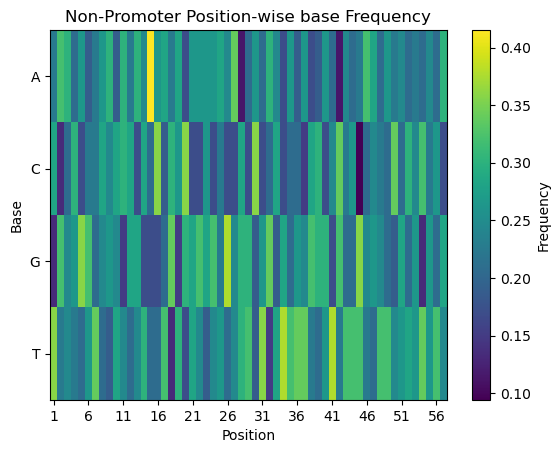

In [17]:
# non-promoter도 heatmap
plt.Figure(figsize=(14,3))
plt.imshow(non_position_frequency_matrix, aspect="auto", cmap="viridis") # non-promoter 클래스의 위치별 염기 빈도 데이터를 히트맵으로 시각화

plt.colorbar(label="Frequency") # 히트맵에 색상 막대 추가하여 빈도 값을 표시
plt.title("Non-Promoter Position-wise base Frequency")
plt.xlabel("Position") # x축 레이블 설정
plt.ylabel("Base") # y축 레이블 설정

plt.yticks(
    ticks=range(len(non_position_frequency_matrix.index)), # y축 눈금 위치 설정
    labels=non_position_frequency_matrix.index # y축 눈금 레이블 설정
)

plt.xticks(
    ticks = range(0, 57, 5), # x축 눈금 위치 설정 (5 간격으로)
    labels = range(1, 58, 5) # x축 눈금 레이블 설정 (1부터 57까지 5 간격으로)
)

plt.show() # 그래프를 화면에 표시

Non-promoter sequence의 위치별 염기 빈도 heatmap은 promoter에 비해 특정 위치에서 강하게 집중된 염기 패턴이 상대적으로 적고, 전반적으로 다양한 염기가 분포하는 양상을 보였다. 반면 promoter sequence에서는 일부 위치 주변에서 특정 염기의 빈도가 높게 나타나, 위치 기반 sequence feature가 promoter 분류에 중요할 수 있음을 확인하였다.

In [18]:
# Quest 4-6. Difference Heatmap
difference_matrix = position_frequency_matrix - non_position_frequency_matrix # promoter와 non-promoter 클래스의 위치별 염기 빈도 차이를 계산하여 새로운 데이터프레임에 저장

print(difference_matrix)

position        1         2         3         4         5         6   \
base                                                                   
A         0.037736  0.000000 -0.037736  0.000000  0.150943  0.415094   
C        -0.056604  0.150943 -0.018868 -0.037736  0.018868 -0.113208   
G         0.018868 -0.188679  0.037736  0.000000 -0.169811 -0.226415   
T         0.000000  0.037736  0.018868  0.037736  0.000000 -0.075472   

position        7         8         9         10  ...        48        49  \
base                                              ...                       
A         0.264151  0.113208  0.018868  0.301887  ...  0.056604 -0.094340   
C        -0.056604 -0.188679 -0.075472 -0.150943  ...  0.150943  0.264151   
G        -0.094340 -0.113208 -0.169811 -0.113208  ... -0.075472  0.075472   
T        -0.113208  0.188679  0.226415 -0.037736  ... -0.132075 -0.245283   

position        50        51        52        53        54       55        56  \
base                   

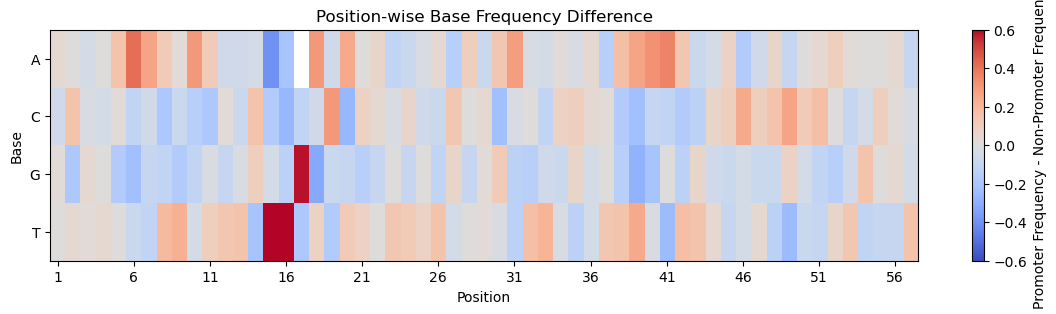

In [19]:
plt.figure(figsize=(14,3))
plt.imshow(difference_matrix, aspect="auto", cmap="coolwarm", vmin=-0.6, vmax=0.6) # promoter와 non-promoter 클래스의 위치별 염기 빈도 차이를 히트맵으로 시각화

plt.colorbar(label="Promoter Frequency - Non-Promoter Frequency") # 히트맵에 색상 막대 추가하여 빈도 차이 값을 표시
plt.title("Position-wise Base Frequency Difference") # 그래프 제목 설정
plt.xlabel("Position") # x축 레이블 설정
plt.ylabel("Base") # y축 레이블 설정

plt.yticks(
    ticks=range(len(difference_matrix.index)), # y축 눈금 위치 설정
    labels=difference_matrix.index # y축 눈금 레이블 설정
)

plt.xticks(
    ticks = range(0, 57, 5), # x축 눈금 위치 설정 (5 간격으로)
    labels = range(1, 58, 5) # x축 눈금 레이블 설정 (1부터 57까지 5 간격으로)
)

plt.show() # 그래프를 화면에 표시

빨간색 → promoter에서 더 자주 등장
파란색 → non-promoter에서 더 자주 등장
흰색 → 두 class가 비슷함

T row, position 15~16 근처가 강한 빨간색
G row, position 17 근처가 강한 빨간색

promoter sequence에서는 15~16번 위치에 T가 non-promoter보다 훨씬 자주 등장한다.
promoter sequence에서는 17번 위치에 G가 non-promoter보다 훨씬 자주 등장한다

Promoter와 non-promoter의 위치별 염기 빈도 차이를 분석한 결과, 특정 위치에서 두 class 간 뚜렷한 염기 분포 차이가 관찰되었다. 특히 position 15~17 부근에서 promoter sequence는 T 및 G 염기의 빈도가 상대적으로 높게 나타났다. 이는 promoter 예측에서 단순 염기 조성뿐 아니라 위치 기반 sequence pattern이 중요한 feature로 작용할 수 있음을 시사한다.

# EDA 인사이트

1. class는 + 53개, - 53개로 균형
2. non-promoter가 평균 GC content가 더 높음
3. promoter는 A/T 비율이 상대적으로 높음
4. promoter는 특정 위치, 특히 15~17 근처에서 뚜렷한 염기 패턴을 보임

In [20]:
# Quest 5-1. 염기 하나를 one-hot으로 바꾸기

def one_hot_base(base):
    if base == "A":
        return [1, 0, 0, 0,] # A를 one-hot 인코딩한 결과
    elif base == "T":
        return [0, 1, 0, 0,] # T를 one-hot 인코딩한 결과
    elif base == "G":
        return [0, 0, 1, 0,] # G를 one-hot 인코딩한 결과
    elif base == "C":
        return [0, 0, 0, 1,] # C를 one-hot 인코딩한 결과
    else:
        return [0, 0, 0, 0,] # 유효하지 않은 염기에 대한 one-hot 인코딩 결과
    
print(one_hot_base("A"))
print(one_hot_base("T"))
print(one_hot_base("G"))
print(one_hot_base("C"))

[1, 0, 0, 0]
[0, 1, 0, 0]
[0, 0, 1, 0]
[0, 0, 0, 1]


In [21]:
# Quest 5-2. sequence 전체를 one-hot으로 바꾸기

def one_hot_sequence(sequence):
    encoded_sequence = []

    for base in sequence: # 시퀀스의 각 염기에 대해 반복
        encoded_base = one_hot_base(base) # 염기를 one-hot 인코딩
        encoded_sequence.append(encoded_base) # 인코딩된 염기 정보를 시퀀스 전체의 인코딩 결과에 추가
    return encoded_sequence

example_sequence = "ATGC"

encoded = one_hot_sequence(example_sequence) # 시퀀스 전체를 one-hot 인코딩

print(encoded)

[[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1]]


In [22]:
# Quest 5-3. one-hot 결과를 한 줄로 펼치기

def flatten_one_hot_sequence(encoded_sequence):
    encoded_sequence = one_hot_sequence(encoded_sequence) # 시퀀스 전체를 one-hot 인코딩

    flattened = []

    for encoded_base in encoded_sequence: # 인코딩된 시퀀스의 각 염기에 대해 반복
        flattened.extend(encoded_base) # 인코딩된 염기 정보를 한 줄로 펼쳐서 최종 결과에 추가
                                       # apeend를 쓰면 리스트 안에 리스트가 들어가지만 estend를 쓰면 값들이 하나씩 들어감
    return flattened

example_sequence = "ATGC"

flattened = flatten_one_hot_sequence(example_sequence) # 시퀀스 전체를 one-hot 인코딩한 후 한 줄로 펼침

print(flattened)
print(len(flattened))

[1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1]
16


In [23]:
# Quest 5-4. 실제 데이터 첫 번째 sequence를 one-hot으로 바꾸기

first_sequence = df.loc[0, "sequence"] # 데이터프레임에서 첫 번째 시퀀스를 가져옴

print(first_sequence)
print(len(first_sequence))

first_vector = flatten_one_hot_sequence(first_sequence)

print(first_vector[:20])
print(len(first_vector))

TACTAGCAATACGCTTGCGTTCGGTGGTTAAGTATGTATAATGCGCGGGCTTGTCGT
57
[0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0]
228


DNA sequence 1개
→ 길이 57의 문자열
→ one-hot 변환
→ 길이 228의 숫자 벡터

In [24]:
X_list = []

for sequence in df["sequence"]: # 데이터프레임의 모든 시퀀스에 대해 반복
    vector = flatten_one_hot_sequence(sequence) # 시퀀스를 one-hot 인코딩한 후 한 줄로 펼침
    X_list.append(vector) # 인코딩된 시퀀스 벡터를 리스트에 추가

X = pd.DataFrame(X_list) # one-hot 인코딩된 시퀀스 벡터 리스트를 데이터프레임으로 변환

print(X.head())
print(X.shape)

   0    1    2    3    4    5    6    7    8    9    ...  218  219  220  221  \
0    0    1    0    0    1    0    0    0    0    0  ...    0    1    0    0   
1    0    1    0    0    0    0    1    0    0    0  ...    0    1    1    0   
2    0    0    1    0    0    1    0    0    1    0  ...    1    0    0    0   
3    1    0    0    0    1    0    0    0    0    1  ...    0    1    0    1   
4    0    1    0    0    0    0    0    1    0    0  ...    0    0    1    0   

   222  223  224  225  226  227  
0    1    0    0    1    0    0  
1    0    0    1    0    0    0  
2    0    1    0    0    1    0  
3    0    0    0    0    0    1  
4    0    0    0    0    1    0  

[5 rows x 228 columns]
(106, 228)


In [25]:
# Quest 5-6. 정답 벡터 y 만들기

y = df["target"] # 데이터프레임에서 target 컬럼을 가져와서 정답 벡터로 사용

print(y.head())
print(y.shape)
print(y.value_counts())

0    1
1    1
2    1
3    1
4    1
Name: target, dtype: int64
(106,)
target
1    53
0    53
Name: count, dtype: int64


106개의 DNA sequence가 있고,
각 sequence는 228개의 숫자 feature로 변환되었으며,
각 sequence마다 promoter/non-promoter 정답이 있다.

In [26]:
# Quest 6-1. Train/Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, # 전체 데이터의 20%를 테스트 세트로 사용
    random_state=42, # 랜덤하게 나누지만, 매번 같은 결과가 나오도록 고정
    stratify=y # train/test에 0과 1의 비율이 비슷하게 들어가도록 해줌
)

print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(84, 228)
(22, 228)
target
0    42
1    42
Name: count, dtype: int64
target
1    11
0    11
Name: count, dtype: int64


In [27]:
# Quest 6-2. Logistic Regression 모델 학습

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42) # 로지스틱 회귀 모델을 생성, 최대 반복 횟수를 1000으로 설정하여 모델이 수렴할 때까지 충분히 학습할 수 있도록 함

model.fit(X_train, y_train) # 훈련 데이터로 모델을 학습

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [28]:
# Quest 6-3. 테스트 데이터 예측하기
y_pred = model.predict(X_test) # 테스트 데이터에 대해 모델이 예측한 라벨을 저장

print(y_pred)
print(y_test.values)

[1 1 0 1 1 0 0 0 1 1 0 1 0 1 0 0 0 0 1 1 1 1]
[1 1 0 1 1 0 0 0 1 1 0 1 0 1 0 0 0 0 0 1 1 1]


In [29]:
# Quest 6-4. Accuracy 계산하기
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred) # 테스트 데이터의 실제 라벨과 모델이 예측한 라벨을 비교하여 정확도를 계산

print("Accuracy:", accuracy)


Accuracy: 0.9545454545454546


In [30]:
# Quest 6-5. Confusion Matrix 보기

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred) # 테스트 데이터의 실제 라벨과 모델이 예측한 라벨을 비교하여 혼동 행렬을 계산

print(cm)

[[10  1]
 [ 0 11]]


[[TN FP]
 [FN TP]]

TN: 실제 0을 0으로 맞힘
FP: 실제 0인데 1로 잘못 예측
FN: 실제 1인데 0으로 잘못 예측
TP: 실제 1을 1로 맞힘

promoter는 전부 잘 맞혔다.
non-promoter 중 1개를 promoter로 착각했다.

In [31]:
# Quest 6-6. Precision, Recall, F1-score

from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred) # 모델이 양성으로 예측한 것 중에서 실제로 양성인 것의 비율을 계산
recall = recall_score(y_test, y_pred) # 실제 양성 중에서 모델이 양성으로 예측한 것의 비율을 계산
f1 = f1_score(y_test, y_pred) # precision과 recall의 조화 평균을 계산하여 F1-score를 구함

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Precision: 0.9166666666666666
Recall: 1.0
F1-score: 0.9565217391304348


Precision: 모델이 promoter라고 예측한 것 중 진짜 promoter 비율

Recall: 실제 promoter 중 모델이 promoter로 찾아낸 비율

F1-score: precision과 recall의 균형 점수

연구 후보 탐색에서는 recall이 높은 모델이 유리할 수 있습니다.
왜냐하면 실제 promoter 후보를 놓치지 않는 게 중요할 수 있기 때문이에요.

하지만 실험 검증 비용이 큰 상황이라면 precision도 중요합니다.
잘못된 promoter 후보가 많아지면 후속 실험 비용이 늘어나기 때문입니다.

최종결과:
Model: Logistic Regression
Input feature: one-hot encoded DNA sequence
Accuracy: 0.955
Precision: 0.917
Recall: 1.000
F1-score: 0.957

In [32]:
# Quest 7. 여러 모델 비교하기



비교할 모델

1. Logistic Regression
2. SVM
3. RandomForest
4. ExtraTrees

In [33]:
# Quest 7-1. 비교할 모델 준비하기

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, random_state=42), # 로지스틱 회귀 모델을 생성
    "SVM" : SVC(kernel="rbf", probability=True, random_state=42), # 서포트 벡터 머신 모델을 생성, RBF 커널을 사용하여 비선형 분류를 수행
    "Random Forest" : RandomForestClassifier(n_estimators=200, random_state=42), # 랜덤 포레스트 모델을 생성, 200개의 결정 트리를 사용하여 앙상블 학습을 수행
    "Extra Trees" : ExtraTreesClassifier(n_estimators=200, random_state=42) # 엑스트라 트리 모델을 생성, 200개의 결정 트리를 사용하여 앙상블 학습을 수행
}
print(models)

{'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42), 'SVM': SVC(probability=True, random_state=42), 'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42), 'Extra Trees': ExtraTreesClassifier(n_estimators=200, random_state=42)}


In [34]:
# Quest 7-2. 모델 하나씩 학습하고 Accuracy 비교하기

from sklearn.metrics import accuracy_score

model_results = []

for model_name, model in models.items(): # 준비된 모델 딕셔너리에서 모델 이름과 모델 객체를 하나씩 가져와서 반복
    model.fit(X_train, y_train) # 모델을 훈련 데이터로 학습

    y_pred = model.predict(X_test) # 테스트 데이터에 대해 모델이 예측한 라벨을 저장

    accuracy = accuracy_score(y_test, y_pred) # 테스트 데이터의 실제 라벨과 모델이 예측한 라벨을 비교하여 정확도를 계산

    model_results.append({
    "model": model_name, # 모델 이름을 결과 리스트에 저장
    "accuracy": accuracy # 모델의 정확도를 결과 리스트에 저장
    })

results_df = pd.DataFrame(model_results) # 모델 비교 결과 리스트를 데이터프레임으로 변환

print(results_df)

                 model  accuracy
0  Logistic Regression  0.954545
1                  SVM  0.954545
2        Random Forest  0.909091
3          Extra Trees  1.000000


동일한 one-hot encoded DNA sequence feature를 사용해 4개 모델을 비교한 결과, 모든 모델이 0.90 이상의 accuracy를 보였다. Extra Trees는 현재 test split에서 1.00의 accuracy를 기록했으며, Logistic Regression과 SVM도 0.955의 높은 accuracy를 보였다.

In [35]:
# Quest 7-3. Accuracy뿐 아니라 Precision, Recall, F1-score 같이 보기

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model_results = []

for model_name, model in models.items(): # 준비된 모델 딕셔너리에서 모델 이름과 모델 객체를 하나씩 가져와서 반복
    model.fit(X_train, y_train) # 모델을 훈련 데이터로 학습

    y_pred = model.predict(X_test) # 테스트 데이터에 대해 모델이 예측한 라벨을 저장

    accuracy = accuracy_score(y_test, y_pred) # 테스트 데이터의 실제 라벨과 모델이 예측한 라벨을 비교하여 정확도를 계산
    precision = precision_score(y_test, y_pred) # 모델이 양성으로 예측한 것 중에서 실제로 양성인 것의 비율을 계산
    recall = recall_score(y_test, y_pred) # 실제 양성 중에서 모델이 양성으로 예측한 것의 비율을 계산
    f1 = f1_score(y_test, y_pred) # precision과 recall의 조화 평균을 계산하여 F1-score를 구함

    model_results.append({
        "model": model_name, # 모델 이름을 결과 리스트에 저장
        "accuracy": accuracy, # 모델의 정확도를 결과 리스트에 저장
        "precision": precision, # 모델의 정밀도를 결과 리스트에 저장
        "recall": recall, # 모델의 재현율을 결과 리스트에 저장
        "f1_score": f1 # 모델의 F1-score를 결과 리스트에 저장
    })

results_df = pd.DataFrame(model_results) # 모델 비교 결과 리스트를 데이터프레임으로 변환

print(results_df)

                 model  accuracy  precision    recall  f1_score
0  Logistic Regression  0.954545   0.916667  1.000000  0.956522
1                  SVM  0.954545   1.000000  0.909091  0.952381
2        Random Forest  0.909091   0.909091  0.909091  0.909091
3          Extra Trees  1.000000   1.000000  1.000000  1.000000


동일한 one-hot encoded sequence feature를 사용하여 Logistic Regression, SVM, Random Forest, Extra Trees 모델을 비교하였다.

단일 train/test split 평가에서 Extra Trees는 accuracy, precision, recall, F1-score 모두 1.000을 기록하였다.

Logistic Regression은 recall 1.000으로 실제 promoter를 모두 탐지했으나 일부 non-promoter를 promoter로 예측하였다.

반면 SVM은 precision 1.000으로 promoter 예측의 정확도는 높았지만 일부 promoter를 놓쳤다. 데이터 수가 106개로 제한적이므로, 단일 split 결과만으로 최종 모델을 결정하기보다 cross validation 기반의 추가 평가가 필요하다.

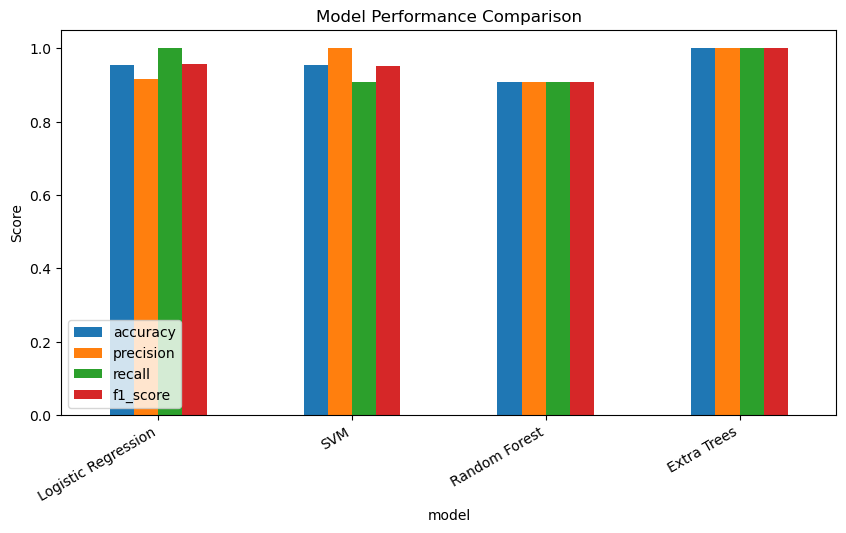

In [36]:
# Quest 7-4. 모델 결과를 막대그래프로 비교하기

results_df.set_index("model")[["accuracy", "precision", "recall", "f1_score"]].plot(kind="bar", figsize=(10,5)) # 모델 이름을 인덱스로 설정하고, 정확도, 정밀도, 재현율, F1-score를 막대 그래프로 시각화

plt.title("Model Performance Comparison") # 그래프 제목 설정
plt.ylabel("Score") # y축 레이블 설정
plt.ylim(0, 1.05) # y축 범위를 0에서 1로 설정하여 점수의 범위를 명확하게 표시
plt.xticks(rotation=30, ha="right") # x축 레이블의 회전 각도를 30도로 설정하고, 레이블이 겹치지 않도록 오른쪽 정렬
plt.legend(loc="lower left") # 범례를 그래프의 왼쪽 아래에 위치하도록 설정
plt.show() # 그래프를 화면에 표시

Extra Trees는 모든 지표에서 1.0으로 가장 높은 성능을 보였다.

Logistic Regression은 recall이 1.0으로 실제 promoter를 모두 탐지했다.

SVM은 precision이 1.0으로 promoter라고 예측한 결과의 신뢰도가 높았다.

Random Forest는 네 지표가 모두 약 0.91로 상대적으로 낮았다.

In [37]:
# Quest 8-1. Logistic Regression Cross Validation

from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5, # 데이터를 5개의 폴드로 나누어 교차 검증을 수행
    shuffle=True, # 데이터를 나누기 전에 섞어서 모델이 데이터의 순서에 의존하지 않도록 함
    random_state=42 # 랜덤하게 나누지만, 매번 같은 결과가 나오도록 고정
)

logistic_model = LogisticRegression(max_iter=1000, random_state=42) # 로지스틱 회귀 모델을 생성

accuracy_scores = cross_val_score(
    logistic_model, # 평가할 모델을 지정
    X, # 전체 데이터의 특성 행렬을 지정
    y, # 전체 데이터의 정답 벡터를 지정
    cv=cv, # 교차 검증 전략을 지정
    scoring="accuracy" # 평가 지표로 정확도를 사용하여 모델의 성능을 측정
)

print("Accuracy Scores:", accuracy_scores)
print("Mean Accuracy:", accuracy_scores.mean())
print("Standard Deviation:", accuracy_scores.std())


Accuracy Scores: [0.90909091 0.9047619  1.         0.95238095 0.80952381]
Mean Accuracy: 0.915151515151515
Standard Deviation: 0.06306692242934826


Logistic Regression은 cross validation 기준 평균 accuracy 약 91.5%를 보였다.

In [38]:
# Quest 8-2. 여러 모델 Cross Validation 비교
cv_results = []

for model_name, model in models.items(): # 준비된 모델 딕셔너리에서 모델 이름과 모델 객체를 하나씩 가져와서 반복
    scores = cross_val_score(
        model, # 평가할 모델을 지정
        X, # 전체 데이터의 특성 행렬을 지정
        y, # 전체 데이터의 정답 벡터를 지정
        cv=cv, # 교차 검증 전략을 지정
        scoring="accuracy" # 평가 지표로 정확도를 사용하여 모델의 성능을 측정
    )

    cv_results.append({
        "model": model_name, # 모델 이름을 결과 리스트에 저장
        "mean_accuracy": scores.mean(), # 모델의 평균 정확도를 결과 리스트에 저장
        "std_accuracy": scores.std(), # 모델의 정확도 표준 편차를 결과 리스트에 저장
        "scores": scores # 모델의 각 폴드에서의 정확도 점수를 결과 리스트에 저장
    })

cv_results_df = pd.DataFrame(cv_results) # 모델 교차 검증 결과 리스트를 데이터프레임으로 변환

print(cv_results_df[["model", "mean_accuracy", "std_accuracy"]]) # 모델 이름, 평균 정확도, 정확도 표준 편차 컬럼을 출력

                 model  mean_accuracy  std_accuracy
0  Logistic Regression       0.915152      0.063067
1                  SVM       0.933766      0.064727
2        Random Forest       0.924242      0.064791
3          Extra Trees       0.943290      0.046753


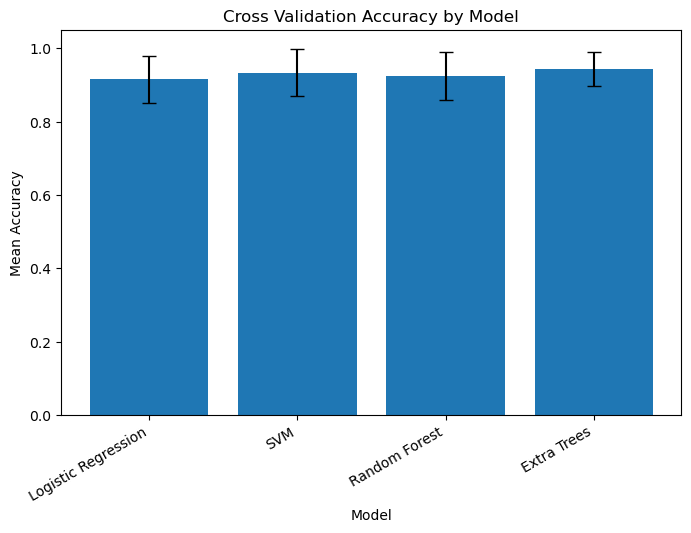

In [39]:
# Quest 8-3. Cross Validation 결과 시각화

plt.figure(figsize=(8, 5))

plt.bar(
    cv_results_df["model"],
    cv_results_df["mean_accuracy"],
    yerr=cv_results_df["std_accuracy"],
    capsize=5
)

plt.title("Cross Validation Accuracy by Model")
plt.xlabel("Model")
plt.ylabel("Mean Accuracy")
plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha="right")
plt.show()

Extra Trees가 평균 accuracy가 가장 높고, error bar도 가장 짧아 가장 안정적인 성능을 보였다.

SVM과 Random Forest도 높은 성능을 보였지만 fold별 변동성이 Extra Trees보다 조금 컸다.

Logistic Regression은 baseline 모델로서 준수한 성능을 보였다.

In [40]:
# Quest 9-1. One-hot feature 이름 만들기

bases = ["A", "T", "G", "C"]

feature_names = []

for position in range(1,58):
    for base in bases:
        feature_name = f"pos_{position}_{base}"
        feature_names.append(feature_name)

print(feature_names[:12])
print(feature_names[-8:])
print(len(feature_names))

['pos_1_A', 'pos_1_T', 'pos_1_G', 'pos_1_C', 'pos_2_A', 'pos_2_T', 'pos_2_G', 'pos_2_C', 'pos_3_A', 'pos_3_T', 'pos_3_G', 'pos_3_C']
['pos_56_A', 'pos_56_T', 'pos_56_G', 'pos_56_C', 'pos_57_A', 'pos_57_T', 'pos_57_G', 'pos_57_C']
228


In [41]:
# Quest 9-2. X 컬럼 이름 붙이기

X.columns = feature_names

print(X.head())
print(X.columns[:12])
print(X.shape)


   pos_1_A  pos_1_T  pos_1_G  pos_1_C  pos_2_A  pos_2_T  pos_2_G  pos_2_C  \
0        0        1        0        0        1        0        0        0   
1        0        1        0        0        0        0        1        0   
2        0        0        1        0        0        1        0        0   
3        1        0        0        0        1        0        0        0   
4        0        1        0        0        0        0        0        1   

   pos_3_A  pos_3_T  ...  pos_55_G  pos_55_C  pos_56_A  pos_56_T  pos_56_G  \
0        0        0  ...         0         1         0         0         1   
1        0        0  ...         0         1         1         0         0   
2        1        0  ...         1         0         0         0         0   
3        0        1  ...         0         1         0         1         0   
4        0        0  ...         0         0         1         0         0   

   pos_56_C  pos_57_A  pos_57_T  pos_57_G  pos_57_C  
0         0   

In [42]:
# Quest 9-3. Extra Trees 모델 다시 학습하기

best_model = ExtraTreesClassifier(
    n_estimators=200,
    random_state=42
)

best_model.fit(X,y)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [43]:
# Quest 9-4. Feature Importance 추출하기

importances = best_model.feature_importances_

importance_df = pd.DataFrame({
    "feature" : X.columns,
    "importance" : importances
})

importance_df = importance_df.sort_values(
    by = "importance",
    ascending=False
).reset_index(drop=True)

print(importance_df.head(20))


     feature  importance
0   pos_16_T    0.060444
1   pos_17_G    0.059255
2   pos_15_T    0.057060
3   pos_15_A    0.042972
4    pos_6_A    0.034476
5   pos_18_G    0.030054
6   pos_39_G    0.025995
7   pos_17_A    0.023332
8   pos_41_A    0.019780
9   pos_39_A    0.012647
10  pos_40_A    0.012604
11  pos_49_T    0.012000
12  pos_20_C    0.011850
13  pos_16_C    0.011368
14   pos_7_A    0.011311
15  pos_10_A    0.011071
16  pos_18_A    0.010551
17  pos_39_T    0.010314
18  pos_16_A    0.008996
19  pos_26_T    0.008844


EDA에서 관찰한 위치별 염기 차이를 모델도 실제로 중요한 feature로 사용했다.

본 분석은 해당 위치의 염기 패턴이 모델 예측에 기여했음을 보여주지만, 실제 생물학적 기능성을 입증하기 위해서는 추가적인 motif 분석 및 문헌 기반 검증이 필요하다.

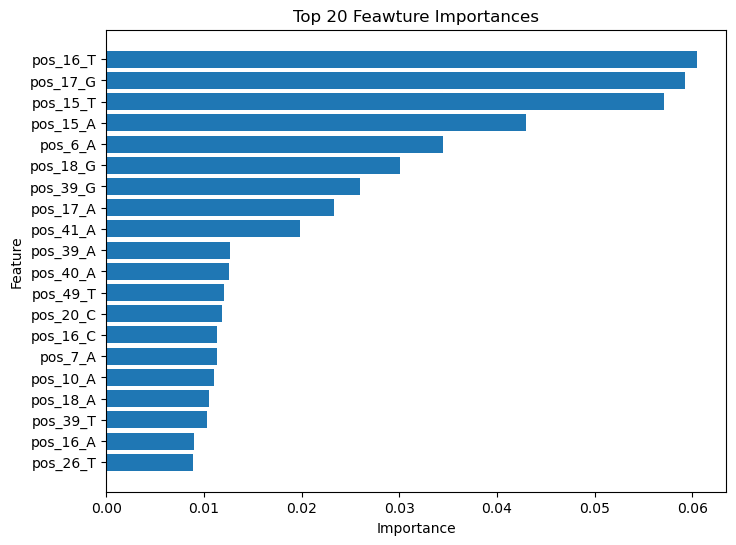

In [44]:
# Quest 9-5. Feature Importance 시각화

top_20_features = importance_df.head(20)

plt.figure(figsize=(8,6))
plt.barh(
    top_20_features["feature"],
    top_20_features["importance"]
)

plt.title("Top 20 Feawture Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

1. DNA sequence 106개를 실제 UCI 데이터에서 불러옴
2. 모든 sequence는 57bp이고, A/T/G/C 외 문자는 없음
3. promoter와 non-promoter는 각각 53개로 균형
4. non-promoter가 평균 GC content가 더 높음
5. promoter는 position 15~18 부근에서 특정 염기 패턴이 두드러짐
6. one-hot encoding으로 sequence를 228개 feature로 변환
7. Extra Trees가 cross validation 기준 가장 높은 평균 accuracy를 보임
8. feature importance에서도 position 15~18 부근 feature가 중요하게 나타남

In [45]:
# Quest 9-6. 중요 feature를 위치와 염기로 분리하기

top_20_features = importance_df.head(20).copy()

top_20_features[["pos_text", "position", "base"]] = top_20_features["feature"].str.split(
    "_",
    expand=True
)

top_20_features["position"] = top_20_features["position"].astype(int)

print(top_20_features)

     feature  importance pos_text  position base
0   pos_16_T    0.060444      pos        16    T
1   pos_17_G    0.059255      pos        17    G
2   pos_15_T    0.057060      pos        15    T
3   pos_15_A    0.042972      pos        15    A
4    pos_6_A    0.034476      pos         6    A
5   pos_18_G    0.030054      pos        18    G
6   pos_39_G    0.025995      pos        39    G
7   pos_17_A    0.023332      pos        17    A
8   pos_41_A    0.019780      pos        41    A
9   pos_39_A    0.012647      pos        39    A
10  pos_40_A    0.012604      pos        40    A
11  pos_49_T    0.012000      pos        49    T
12  pos_20_C    0.011850      pos        20    C
13  pos_16_C    0.011368      pos        16    C
14   pos_7_A    0.011311      pos         7    A
15  pos_10_A    0.011071      pos        10    A
16  pos_18_A    0.010551      pos        18    A
17  pos_39_T    0.010314      pos        39    T
18  pos_16_A    0.008996      pos        16    A
19  pos_26_T    0.00

In [46]:
# Quest 9-7. 위치별 중요도 합계 보기

importance_df_split = importance_df.copy()

importance_df_split[["pos_text", "position", "base"]] = importance_df_split["feature"].str.split(
    "_",
    expand=True
)

importance_df_split["position"] = importance_df_split["position"].astype(int)

position_importance = (
    importance_df_split
    .groupby("position")["importance"]
    .sum()
    .reset_index()
    .sort_values("importance", ascending=False)
)

print(position_importance.head(15))

    position  importance
14        15    0.109543
16        17    0.093913
15        16    0.085024
38        39    0.057628
17        18    0.043528
5          6    0.042627
40        41    0.031671
48        49    0.024903
39        40    0.022040
19        20    0.021605
9         10    0.017529
6          7    0.017105
25        26    0.015734
32        33    0.014453
29        30    0.014363


Feature importance를 position 단위로 합산한 결과, position 15, 16, 17, 18이 상위 중요 위치로 나타났다. 이는 앞선 position-wise frequency difference heatmap에서 관찰된 class 간 차이와 일치한다. 따라서 본 모델은 promoter 예측 과정에서 특정 위치 주변의 염기 패턴을 주요하게 활용한 것으로 해석할 수 있다.

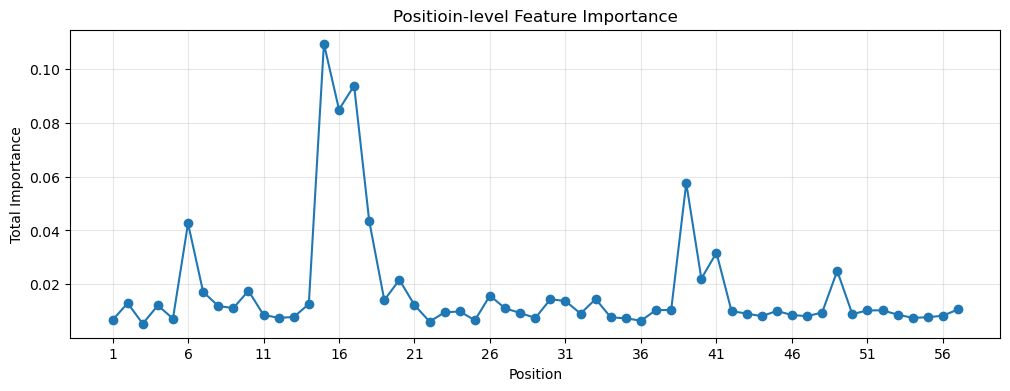

In [47]:
# Quest 9-8. 위치별 중요도 그래프 그리기
position_importance_sorted = position_importance.sort_values("position")

plt.figure(figsize=(12,4))
plt.plot(
    position_importance_sorted["position"],
    position_importance_sorted["importance"],
    marker="o"
)

plt.title("Positioin-level Feature Importance")
plt.xlabel("Position")
plt.ylabel("Total Importance")
plt.xticks(range(1,58,5))
plt.grid(alpha=0.3)
plt.show()


EDA heatmap
→ position 15~18 부근에서 promoter/non-promoter 차이 관찰

Extra Trees feature importance
→ pos_15_T, pos_16_T, pos_17_G, pos_18_G 등이 중요 feature로 나타남

position-level importance
→ position 15~18이 가장 중요한 위치 구간으로 확인됨

본 결과는 position 15~18 부근의 염기 패턴이 모델 예측에 크게 기여했음을 보여준다. 다만 해당 위치의 실제 생물학적 기능성을 입증하기 위해서는 motif database 또는 문헌 기반 추가 검증이 필요하다.

본 프로젝트는 E. coli DNA sequence 데이터를 이용해 promoter 여부를 예측하는 머신러닝 모델을 구축하고, position-wise feature importance 분석을 통해 promoter 예측에 중요한 sequence pattern을 해석하였다.

-----------------------------------------------------------------

프로젝트명:
DNA 염기서열 기반 Promoter 분류 모델 개발

프로젝트 목적:
E. coli DNA sequence를 기반으로 promoter와 non-promoter를 분류하는 머신러닝 모델을 구축하고, 모델 해석을 통해 예측에 중요한 위치별 염기 패턴을 탐색한다.

데이터:
UCI Molecular Biology Promoter Gene Sequences 데이터셋
총 106개 sequence
promoter 53개, non-promoter 53개
모든 sequence 길이 57bp
A/T/G/C 외 이상 염기 없음

사용 feature:
1. One-hot encoded sequence feature
2. GC content 분석
3. 위치별 염기 빈도 분석
4. Feature importance 기반 위치별 중요도

사용 모델:
Logistic Regression
SVM
Random Forest
Extra Trees

주요 결과:
5-fold Stratified Cross Validation 결과 Extra Trees가 평균 accuracy 94.33%, 표준편차 4.68%로 가장 높은 성능을 보였다.

주요 인사이트:
Promoter와 non-promoter는 GC content 및 위치별 염기 분포에서 차이를 보였다.
특히 position 15~18 부근의 염기 패턴이 모델 예측에 중요한 feature로 나타났다.

한계점:
데이터 수가 106개로 작아 일반화 성능 검증에는 한계가 있다.
E. coli 데이터에 한정되어 다른 종이나 인간 유전체 데이터로 확장 검증이 필요하다.
Feature importance는 모델 기반 해석이므로 실제 생물학적 기능 검증은 추가 분석이 필요하다.

확장 방향:
k-mer feature 추가
SHAP 기반 모델 해석
Streamlit 예측 데모 앱 제작
TCGA 또는 GEO 기반 정밀의료 데이터 분석 프로젝트로 확장

In [49]:
# Quest 11-1. k-mer 직접 만들어보기
example_sequence = "ATGCG"
k = 3

kmers = []
# sequence를 일정 길이 k로 자르고, 한 칸씩 이동하면서 패턴을 추출한다.
for i in range(len(example_sequence) - k + 1):
    kmer = example_sequence[i:i+k]
    kmers.append(kmer)

print(kmers)

['ATG', 'TGC', 'GCG']


In [50]:
# Quest 11-2. k-mer를 함수로 만들기

def make_kmers(sequence, k):
    kmers = []

    for i in range(len(sequence) - k + 1):
        kmer = sequence[i:i+k]
        kmers.append(kmer)
    return kmers

print(make_kmers("ATGCG", 3))
print(make_kmers("TATAAT", 3))

['ATG', 'TGC', 'GCG']
['TAT', 'ATA', 'TAA', 'AAT']


In [51]:
# Quest 11-3. 실제 첫 번째 sequence에서 3-mer 만들기

first_sequence = df.loc[0, "sequence"]

first_kmers = make_kmers(first_sequence, 3)

print(first_sequence)
print(len(first_sequence))
print(first_kmers[:10])
print(len(first_kmers))

TACTAGCAATACGCTTGCGTTCGGTGGTTAAGTATGTATAATGCGCGGGCTTGTCGT
57
['TAC', 'ACT', 'CTA', 'TAG', 'AGC', 'GCA', 'CAA', 'AAT', 'ATA', 'TAC']
55


In [53]:
# Quest 11-4. k-mer 개수 세기
from collections import Counter

example_kmers = ["TAT", "ATA", "TAT", "AAT"]

kmer_counts = Counter(example_kmers)

print(kmer_counts)
print(kmer_counts["TAT"])
print(kmer_counts["ATA"])


Counter({'TAT': 2, 'ATA': 1, 'AAT': 1})
2
1


In [ ]:
# Quest 11-5. 첫 번째 sequence의 3-mer count 보기

first_kmer_counts = Counter(first_kmers)

print(first_kmer_counts)
print(first_kmer_counts.most_common(10)) # most_common(10)) 자주 등장한 10개만 보여줌

Counter({'GCG': 3, 'TAC': 2, 'AAT': 2, 'ATA': 2, 'CGC': 2, 'GCT': 2, 'CTT': 2, 'TTG': 2, 'TGC': 2, 'CGT': 2, 'GTT': 2, 'TCG': 2, 'CGG': 2, 'GGT': 2, 'TAA': 2, 'GTA': 2, 'TAT': 2, 'ATG': 2, 'TGT': 2, 'ACT': 1, 'CTA': 1, 'TAG': 1, 'AGC': 1, 'GCA': 1, 'CAA': 1, 'ACG': 1, 'TTC': 1, 'GTG': 1, 'TGG': 1, 'TTA': 1, 'AAG': 1, 'AGT': 1, 'GGG': 1, 'GGC': 1, 'GTC': 1})
[('GCG', 3), ('TAC', 2), ('AAT', 2), ('ATA', 2), ('CGC', 2), ('GCT', 2), ('CTT', 2), ('TTG', 2), ('TGC', 2), ('CGT', 2)]


In [55]:
# Quest 11-6. 전체 데이터에서 등장한 3-mer vocabulary 만들기

all_kmers = []

for sequence in df["sequence"]:
    kmers = make_kmers(sequence, 3)
    all_kmers.extend(kmers)

kmer_vocabulary = sorted(set(all_kmers))

print(kmer_vocabulary[:20])
print(len(kmer_vocabulary))

['AAA', 'AAC', 'AAG', 'AAT', 'ACA', 'ACC', 'ACG', 'ACT', 'AGA', 'AGC', 'AGG', 'AGT', 'ATA', 'ATC', 'ATG', 'ATT', 'CAA', 'CAC', 'CAG', 'CAT']
64


In [57]:
# Quest 11-7. sequence 하나를 3-mer count vector로 바꾸기

first_kmer_counts = Counter(make_kmers(first_sequence, 3))

first_kmer_vector = []

for kmer in kmer_vocabulary:
    count = first_kmer_counts[kmer]
    first_kmer_vector.append(count)

print(first_kmer_vector[:20])
print(len(first_kmer_vector))
print(sum(first_kmer_vector))

[0, 0, 1, 2, 0, 0, 1, 1, 0, 1, 0, 1, 2, 0, 2, 0, 1, 0, 0, 0]
64
55


DNA sequence 1개

→ 3-mer 55개 추출

→ 64개 vocabulary 기준 count vector 생성

→ vector 합계 = 55

In [58]:
# Quest 11-8. 전체 데이터의 k-mer feature matrix 만들기

X_kmer_list = []

for sequence in df["sequence"]:
    kmer_counts = Counter(make_kmers(sequence, 3))

    kmer_vector = []

    for kmer in kmer_vocabulary:
        count = kmer_counts[kmer]
        kmer_vector.append(count)

    X_kmer_list.append(kmer_vector)

X_kmer = pd.DataFrame(
    X_kmer_list,
    columns=[f"3mer_{kmer}" for kmer in kmer_vocabulary]
)

print(X_kmer.head())
print(X_kmer.shape)


   3mer_AAA  3mer_AAC  3mer_AAG  3mer_AAT  3mer_ACA  3mer_ACC  3mer_ACG  \
0         0         0         1         2         0         0         1   
1         0         1         0         1         2         0         2   
2         0         2         0         0         0         2         0   
3         1         2         1         2         1         0         0   
4         4         2         1         2         0         1         1   

   3mer_ACT  3mer_AGA  3mer_AGC  ...  3mer_TCG  3mer_TCT  3mer_TGA  3mer_TGC  \
0         1         0         1  ...         2         0         0         2   
1         0         0         0  ...         2         1         2         1   
2         2         2         1  ...         0         0         0         2   
3         2         2         0  ...         1         0         1         1   
4         2         1         1  ...         1         0         2         1   

   3mer_TGG  3mer_TGT  3mer_TTA  3mer_TTC  3mer_TTG  3mer_TTT  
0   

In [62]:
# Quest 12-1. k-mer feature로 모델 비교하기

kmer_cv_results = []

for model_name, model in models.items():
    scores = cross_val_score(
        model,
        X_kmer,
        y,
        cv=cv,
        scoring="accuracy"
    )

    kmer_cv_results.append({
        "model": model_name,
        "mean_accuracy": scores.mean(),
        "std_accuracy": scores.std()
    })

kmer_cv_results_df = pd.DataFrame(kmer_cv_results)

print(kmer_cv_results_df)

                 model  mean_accuracy  std_accuracy
0  Logistic Regression       0.867965      0.076072
1                  SVM       0.915152      0.063067
2        Random Forest       0.934199      0.037480
3          Extra Trees       0.924675      0.048252


In [63]:
# Quest 12-2. one-hot 결과와 k-mer 결과 비교하기

onehot_compare = cv_results_df[["model", "mean_accuracy", "std_accuracy"]].copy()
onehot_compare["feature_set"] = "one-hot"

kmer_compare = kmer_cv_results_df[["model", "mean_accuracy", "std_accuracy"]].copy()
kmer_compare["feature_set"] = "3-mer"

feature_compare_df = pd.concat(
    [onehot_compare, kmer_compare],
    axis=0
).reset_index(drop=True)

print(feature_compare_df)

                 model  mean_accuracy  std_accuracy feature_set
0  Logistic Regression       0.915152      0.063067     one-hot
1                  SVM       0.933766      0.064727     one-hot
2        Random Forest       0.924242      0.064791     one-hot
3          Extra Trees       0.943290      0.046753     one-hot
4  Logistic Regression       0.867965      0.076072       3-mer
5                  SVM       0.915152      0.063067       3-mer
6        Random Forest       0.934199      0.037480       3-mer
7          Extra Trees       0.924675      0.048252       3-mer


one-hot feature는 위치별 염기 정보를 보존하기 때문에 position-specific pattern을 잘 활용하는 Extra Trees에서 가장 좋은 성능을 보였다.

3-mer count feature는 짧은 sequence pattern의 빈도 정보를 반영하며, Random Forest가 가장 안정적인 성능을 보였다.

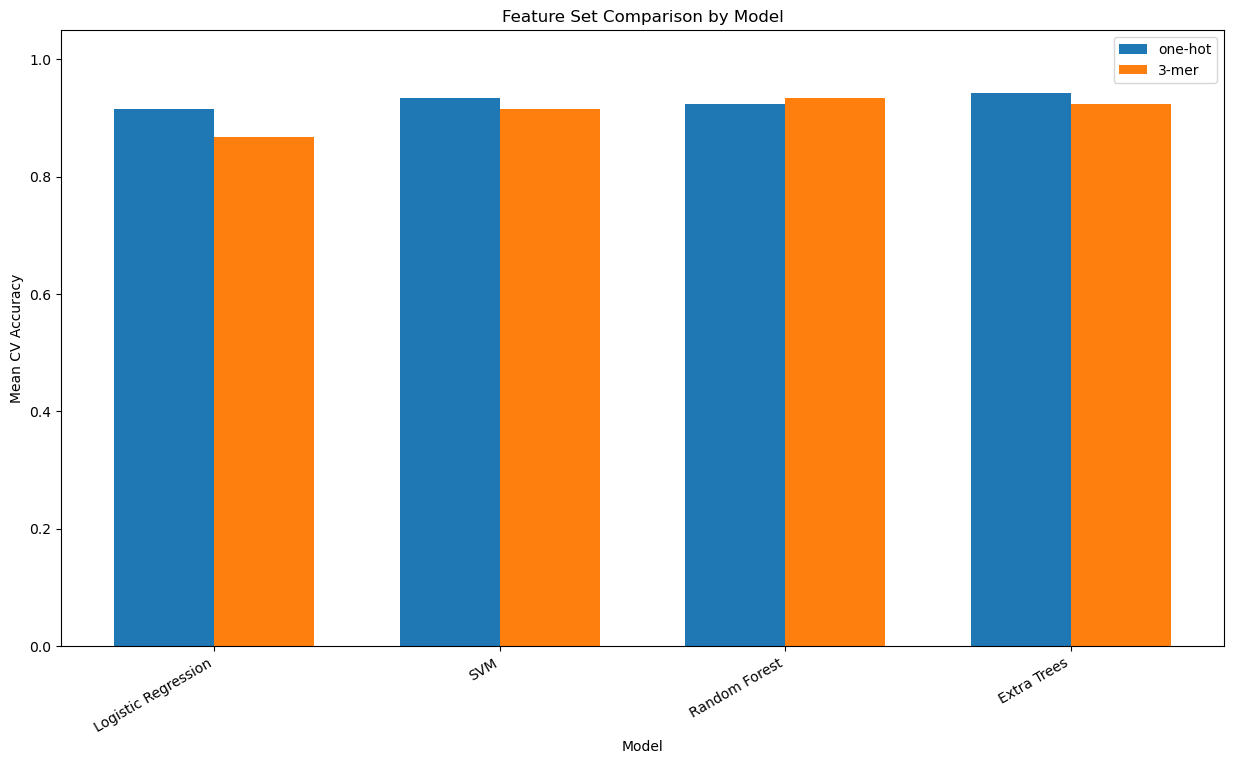

In [68]:
# Quest 12-3. Feature set 비교 그래프 그리기

import numpy as np

models_order = feature_compare_df["model"].unique()

onehot_scores = feature_compare_df[
    feature_compare_df["feature_set"] == "one-hot"
]["mean_accuracy"].values

kmer_scores = feature_compare_df[
    feature_compare_df["feature_set"] == "3-mer"
]["mean_accuracy"].values

x = np.arange(len(models_order))
width = 0.35

plt.figure(figsize=(15,8))

plt.bar(
    x - width / 2,
    onehot_scores,
    width,
    label="one-hot"
)

plt.bar(
    x + width / 2,
    kmer_scores,
    width,
    label="3-mer"
)

plt.title("Feature Set Comparison by Model")
plt.xlabel("Model")
plt.ylabel("Mean CV Accuracy")
plt.xticks(x, models_order, rotation=30, ha="right")
plt.ylim(0, 1.05)
plt.legend()
plt.show()

Logistic Regression:
one-hot이 3-mer보다 확실히 높음

SVM:
one-hot이 3-mer보다 약간 높음

Random Forest:
3-mer가 one-hot보다 약간 높음

Extra Trees:
one-hot이 3-mer보다 높음

One-hot encoding과 3-mer count feature를 비교한 결과, 대부분의 모델에서 위치 정보를 보존하는 one-hot feature가 더 높은 성능을 보였다. 특히 Extra Trees는 one-hot feature에서 평균 CV accuracy 94.33%로 가장 높은 성능을 기록하였다. 반면 Random Forest는 3-mer feature에서 더 높은 성능을 보여, k-mer 기반 motif-like pattern도 promoter 분류에 유용한 정보를 제공할 수 있음을 확인하였다.

In [69]:
# Quest 13. one-hot + 3-mer 통합 feature 만들기

X_combined = pd.concat(
    [X, X_kmer],
    axis=1
)

print(X.shape)
print(X_kmer.shape)
print(X_combined.shape)
print(X_combined.head())

(106, 228)
(106, 64)
(106, 292)
   pos_1_A  pos_1_T  pos_1_G  pos_1_C  pos_2_A  pos_2_T  pos_2_G  pos_2_C  \
0        0        1        0        0        1        0        0        0   
1        0        1        0        0        0        0        1        0   
2        0        0        1        0        0        1        0        0   
3        1        0        0        0        1        0        0        0   
4        0        1        0        0        0        0        0        1   

   pos_3_A  pos_3_T  ...  3mer_TCG  3mer_TCT  3mer_TGA  3mer_TGC  3mer_TGG  \
0        0        0  ...         2         0         0         2         1   
1        0        0  ...         2         1         2         1         1   
2        1        0  ...         0         0         0         2         0   
3        0        1  ...         1         0         1         1         0   
4        0        0  ...         1         0         2         1         1   

   3mer_TGT  3mer_TTA  3mer_TTC  3me

one-hot feature: 228개

3-mer feature: 64개

combined feature: 292개

In [72]:
# Quest 13-2. combined feature로 모델 비교하기

combined_cv_results = []

for model_name, model in models.items():
    scores = cross_val_score(
        model,
        X_combined,
        y,
        cv=cv,
        scoring="accuracy"
    )

    combined_cv_results.append({
        "model": model_name,
        "mean_accuracy": scores.mean(),
        "std_accuracy": scores.std()
    })

combined_cv_results_df = pd.DataFrame(combined_cv_results)

print(combined_cv_results_df)


                 model  mean_accuracy  std_accuracy
0  Logistic Regression       0.924242      0.048824
1                  SVM       0.924675      0.048252
2        Random Forest       0.971861      0.037888
3          Extra Trees       0.961905      0.055533


위치 정보 + k-mer 패턴 정보를 결합하자 성능이 향상되었다.

One-hot feature와 3-mer count feature를 결합한 combined feature set을 구성한 결과, Random Forest 모델이 5-fold Stratified Cross Validation에서 평균 accuracy 97.19%, 표준편차 3.79%로 가장 높은 성능을 보였다. 이는 위치 기반 염기 정보와 k-mer 기반 motif-like pattern 정보가 상호보완적으로 작용하여 promoter classification 성능을 향상시킬 수 있음을 시사한다.

In [73]:
# Quest 13-3. 세 가지 feature set 한 번에 비교하기

combined_compare = combined_cv_results_df[["model", "mean_accuracy", "std_accuracy"]].copy()
combined_compare["feature_set"] = "combined"

all_feature_compare_df = pd.concat(
    [onehot_compare, kmer_compare, combined_compare],
    axis=0
).reset_index(drop=True)

print(all_feature_compare_df)

                  model  mean_accuracy  std_accuracy feature_set
0   Logistic Regression       0.915152      0.063067     one-hot
1                   SVM       0.933766      0.064727     one-hot
2         Random Forest       0.924242      0.064791     one-hot
3           Extra Trees       0.943290      0.046753     one-hot
4   Logistic Regression       0.867965      0.076072       3-mer
5                   SVM       0.915152      0.063067       3-mer
6         Random Forest       0.934199      0.037480       3-mer
7           Extra Trees       0.924675      0.048252       3-mer
8   Logistic Regression       0.924242      0.048824    combined
9                   SVM       0.924675      0.048252    combined
10        Random Forest       0.971861      0.037888    combined
11          Extra Trees       0.961905      0.055533    combined


one-hot:
Extra Trees, 94.33%

3-mer:
Random Forest, 93.42%

combined:
Random Forest, 97.19%

one-hot과 3-mer를 결합한 combined feature set이 가장 좋은 성능을 보였다.

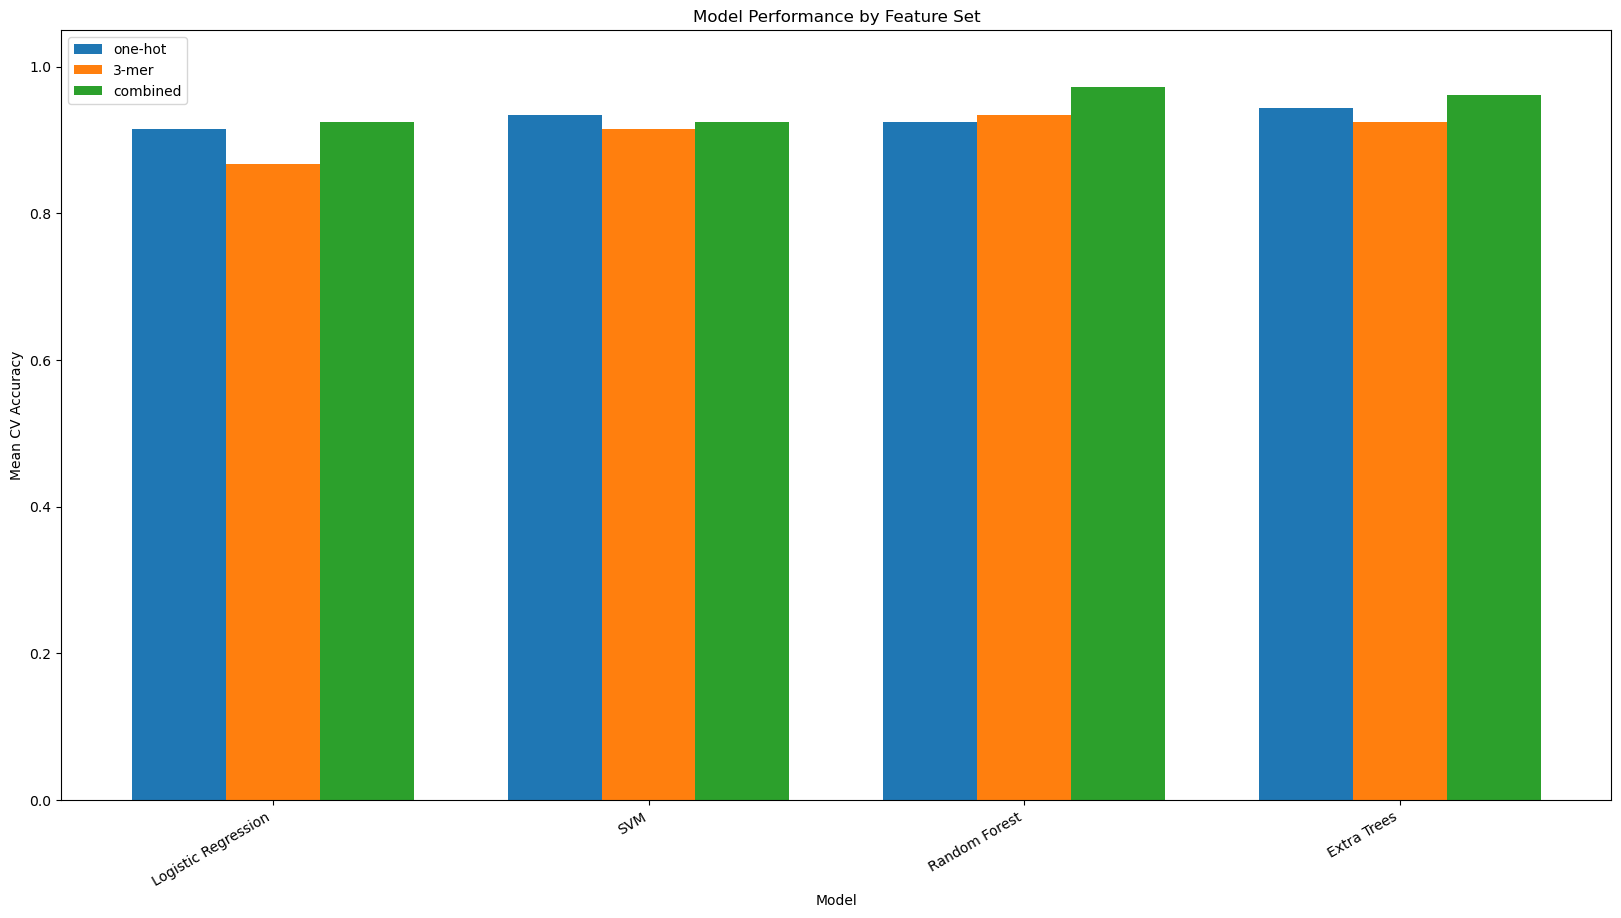

In [78]:
# Quest 13-4. 최종 feature set 비교 그래프

models_order = ["Logistic Regression", "SVM", "Random Forest", "Extra Trees"]
feature_sets = ["one-hot", "3-mer", "combined"]

x = np.arange(len(models_order))
width = 0.25

plt.figure(figsize=(20,10))

for i, feature_set in enumerate(feature_sets):
    subset = all_feature_compare_df[
        all_feature_compare_df["feature_set"] == feature_set
    ]

    scores = []

    for model_name in models_order:
        score = subset[subset["model"] == model_name]["mean_accuracy"].values[0]
        scores.append(score)
    
    plt.bar(
        x + (i - 1) * width,
        scores,
        width,
        label=feature_set
    )

plt.title("Model Performance by Feature Set")
plt.xlabel("Model")
plt.ylabel("Mean CV Accuracy")
plt.xticks(x, models_order, rotation=30, ha="right")
plt.ylim(0, 1.05)
plt.legend()
plt.show()

Logistic Regression:
combined가 3-mer보다 높고, one-hot과 비슷하거나 약간 높음

SVM:
one-hot이 가장 높고, combined와 3-mer는 비슷한 수준

Random Forest:
combined가 가장 높음

Extra Trees:
combined가 높고, one-hot도 강함

DNA promoter classification에서 위치 기반 one-hot feature와 3-mer count feature를 결합했을 때 가장 높은 성능을 보였으며, 특히 Random Forest 모델이 평균 CV accuracy 97.19%로 가장 우수했다.

7월 15일